In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)


In [23]:
df = pd.read_csv("Social_Network_Ads.csv")

In [24]:
# =========================================================
# STEP 3 - DISPLAY DATASET
# =========================================================

print("FIRST 5 ROWS OF DATASET:\n")
print(df.head())

print("\nLAST 5 ROWS OF DATASET:\n")
print(df.tail())

FIRST 5 ROWS OF DATASET:

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510    Male   19            19000          0
1  15810944    Male   35            20000          0
2  15668575  Female   26            43000          0
3  15603246  Female   27            57000          0
4  15804002    Male   19            76000          0

LAST 5 ROWS OF DATASET:

      User ID  Gender  Age  EstimatedSalary  Purchased
395  15691863  Female   46            41000          1
396  15706071    Male   51            23000          1
397  15654296  Female   50            20000          1
398  15755018    Male   36            33000          0
399  15594041  Female   49            36000          1


In [25]:
# =========================================================
# STEP 4 - DROP UNNECESSARY COLUMN
# =========================================================

# Remove User ID column if present

if 'User ID' in df.columns:
    df = df.drop('User ID', axis=1)


In [5]:
# =========================================================
# STEP 5 - BASIC DATASET INFORMATION
# =========================================================

print("\nDATASET SHAPE:\n")
print(df.shape)

print("\nCOLUMN NAMES:\n")
print(df.columns)

print("\nDATATYPES:\n")
print(df.dtypes)

print("\nDATASET INFO:\n")
print(df.info())

print("\nSTATISTICAL SUMMARY:\n")
print(df.describe())



DATASET SHAPE:

(400, 4)

COLUMN NAMES:

Index(['Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

DATATYPES:

Gender             object
Age                 int64
EstimatedSalary     int64
Purchased           int64
dtype: object

DATASET INFO:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Gender           400 non-null    object
 1   Age              400 non-null    int64 
 2   EstimatedSalary  400 non-null    int64 
 3   Purchased        400 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 12.6+ KB
None

STATISTICAL SUMMARY:

              Age  EstimatedSalary   Purchased
count  400.000000       400.000000  400.000000
mean    37.655000     69742.500000    0.357500
std     10.482877     34096.960282    0.479864
min     18.000000     15000.000000    0.000000
25%     29.750000     43000.000000    0.000000
50%

In [6]:
# =========================================================
# STEP 6 - CHECK MISSING VALUES
# =========================================================

print("\nMISSING VALUES:\n")
print(df.isnull().sum())

# =========================================================
# STEP 7 - CONVERT CATEGORICAL DATA TO NUMERIC
# =========================================================

# Male -> 1
# Female -> 0

df['Gender'] = df['Gender'].map({
    'Male': 1,
    'Female': 0
})

print("\nDATASET AFTER GENDER CONVERSION:\n")
print(df.head())


MISSING VALUES:

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

DATASET AFTER GENDER CONVERSION:

   Gender  Age  EstimatedSalary  Purchased
0       1   19            19000          0
1       1   35            20000          0
2       0   26            43000          0
3       0   27            57000          0
4       1   19            76000          0


In [7]:
# =========================================================
# STEP 8 - SELECT FEATURES AND TARGET
# =========================================================

# Independent Variables (Input Features)

X = df.drop('Purchased', axis=1)

# Dependent Variable (Target)

y = df['Purchased']

print("\nFEATURES SHAPE:", X.shape)
print("TARGET SHAPE:", y.shape)


FEATURES SHAPE: (400, 3)
TARGET SHAPE: (400,)


In [8]:

# =========================================================
# STEP 9 - TRAIN TEST SPLIT
# =========================================================

# 80% Training Data
# 20% Testing Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nX_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)


X_train Shape: (320, 3)
X_test Shape: (80, 3)
y_train Shape: (320,)
y_test Shape: (80,)


In [9]:
# =========================================================
# STEP 10 - FEATURE SCALING
# =========================================================

# Standardization Formula:
# z = (x - mean) / standard deviation

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)



In [10]:
model = LogisticRegression()

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [11]:

# =========================================================
# STEP 12 - MODEL ACCURACY
# =========================================================

# score() returns accuracy for classification models

model_accuracy = model.score(X_test, y_test)

print("\nMODEL ACCURACY SCORE:")
print(model_accuracy)



MODEL ACCURACY SCORE:
0.8875


In [12]:
# =========================================================
# STEP 13 - PREDICTION
# =========================================================

y_pred = model.predict(X_test)

print("\nPREDICTED VALUES:\n")
print(y_pred)

print("\nACTUAL VALUES:\n")
print(y_test.values)


PREDICTED VALUES:

[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 1 0 0
 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0
 0 0 1 1 0 0]

ACTUAL VALUES:

[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0
 1 0 1 1 0 1]


In [13]:
# =========================================================
# STEP 14 - ACTUAL VS PREDICTED TABLE
# =========================================================

result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("\nACTUAL VS PREDICTED:\n")
print(result.head(20))


ACTUAL VS PREDICTED:

    Actual  Predicted
0        0          0
1        1          1
2        0          0
3        1          1
4        0          0
5        0          0
6        1          1
7        0          0
8        0          0
9        0          0
10       0          0
11       1          1
12       0          0
13       0          0
14       0          0
15       0          0
16       1          1
17       0          1
18       0          0
19       1          1


In [14]:
# =========================================================
# STEP 15 - CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX:\n")
print(cm)


CONFUSION MATRIX:

[[50  2]
 [ 7 21]]


In [15]:
# =========================================================
# STEP 16 - FIND TP, TN, FP, FN
# =========================================================

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("\nTRUE POSITIVE (TP):", TP)
print("TRUE NEGATIVE (TN):", TN)
print("FALSE POSITIVE (FP):", FP)
print("FALSE NEGATIVE (FN):", FN)



TRUE POSITIVE (TP): 21
TRUE NEGATIVE (TN): 50
FALSE POSITIVE (FP): 2
FALSE NEGATIVE (FN): 7


In [16]:
# =========================================================
# STEP 17 - PERFORMANCE METRICS
# =========================================================

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Error Rate
error_rate = 1 - accuracy

# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

print("\nPERFORMANCE METRICS:\n")

print("Accuracy:", accuracy)

print("Error Rate:", error_rate)

print("Precision:", precision)

print("Recall:", recall)



PERFORMANCE METRICS:

Accuracy: 0.8875
Error Rate: 0.11250000000000004
Precision: 0.9130434782608695
Recall: 0.75


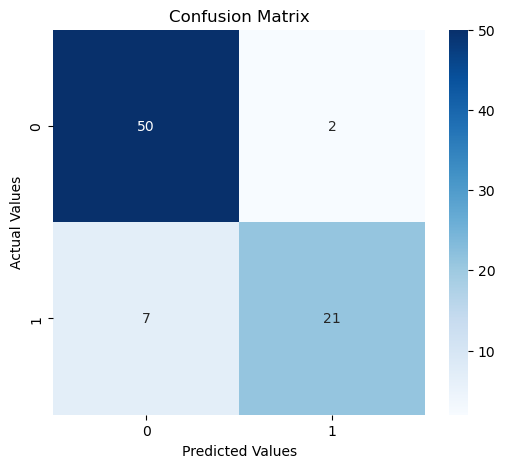

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Values")

plt.ylabel("Actual Values")

plt.title("Confusion Matrix")

plt.show()



MODEL COEFFICIENTS:

[[0.13721002 1.98963144 1.14512193]]

MODEL INTERCEPT:

[-1.00504843]


In [20]:
# =========================================================
# STEP 20 - PREDICT FOR NEW CUSTOMER
# =========================================================

# Example Customer:
# Gender = Male -> 1
# Age = 35
# Salary = 60000

new_customer = [[1, 35, 60000]]

# Apply same scaling

new_customer_scaled = scaler.transform(new_customer)

# Prediction

prediction = model.predict(new_customer_scaled)

# Probability Prediction

probability = model.predict_proba(new_customer_scaled)

print("\nNEW CUSTOMER PREDICTION:\n")

if prediction[0] == 1:
    print("Customer Will Purchase")
else:
    print("Customer Will Not Purchase")

print("\nPREDICTION PROBABILITIES:\n")
print(probability)



NEW CUSTOMER PREDICTION:

Customer Will Not Purchase

PREDICTION PROBABILITIES:

[[0.85457876 0.14542124]]


C:\Users\user\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [21]:
# =========================================================
# STEP 17 - PERFORMANCE METRICS USING FORMULAS
# =========================================================

# Accuracy Formula:
# Accuracy = (TP + TN) / (TP + TN + FP + FN)

accuracy = (TP + TN) / (TP + TN + FP + FN)

# ---------------------------------------------------------

# Error Rate Formula:
# Error Rate = (FP + FN) / (TP + TN + FP + FN)

error_rate = (FP + FN) / (TP + TN + FP + FN)

# ---------------------------------------------------------

# Precision Formula:
# Precision = TP / (TP + FP)

precision = TP / (TP + FP)

# ---------------------------------------------------------

# Recall Formula:
# Recall = TP / (TP + FN)

recall = TP / (TP + FN)

# =========================================================
# DISPLAY PERFORMANCE METRICS
# =========================================================

print("\nPERFORMANCE METRICS:\n")

print("Accuracy:", accuracy)

print("Error Rate:", error_rate)

print("Precision:", precision)

print("Recall:", recall)


PERFORMANCE METRICS:

Accuracy: 0.8875
Error Rate: 0.1125
Precision: 0.9130434782608695
Recall: 0.75
